In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\sandu\Downloads\Data Set For Task\3) Sentiment dataset.csv')
print(df.head())
print(df.shape)
print(df.columns.tolist())

   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                     Hashtags  Retweets  Likes     

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Download required nltk data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sandu\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sandu\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sandu\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [17]:
# Extra cleaning - strip all whitespace from Sentiment column
df['Sentiment'] = df['Sentiment'].str.strip()

# Keep only valid sentiments
df = df[df['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])]

print("Sentiment counts after cleaning:")
print(df['Sentiment'].value_counts())

Sentiment counts after cleaning:
Sentiment
Positive    45
Neutral     18
Negative     4
Name: count, dtype: int64


In [6]:
def get_textblob_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

df['TB_Sentiment'] = df['Cleaned_Text'].apply(get_textblob_sentiment)
df['Polarity'] = df['Cleaned_Text'].apply(get_polarity)
df['Subjectivity'] = df['Cleaned_Text'].apply(get_subjectivity)

print("TextBlob sentiment analysis done!")
print("\nTextBlob Sentiment counts:")
print(df['TB_Sentiment'].value_counts())

TextBlob sentiment analysis done!

TextBlob Sentiment counts:
TB_Sentiment
Neutral     331
Positive    282
Negative    119
Name: count, dtype: int64


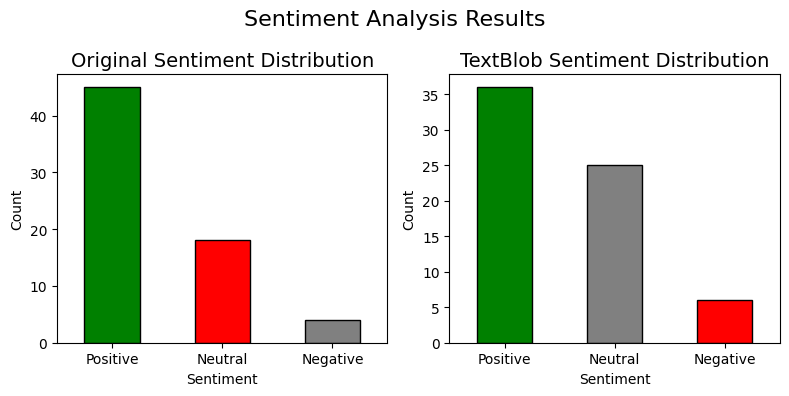

Sentiment distribution chart saved!


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Fix - filter only 3 main sentiments
sentiment_counts = df['Sentiment'].value_counts()
sentiment_filtered = sentiment_counts[sentiment_counts.index.isin(['Positive', 'Negative', 'Neutral'])]

# Original sentiment distribution
sentiment_filtered.plot(
    kind='bar',
    ax=axes[0],
    color=['green', 'red', 'gray'],
    edgecolor='black'
)
axes[0].set_title('Original Sentiment Distribution', fontsize=14)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# TextBlob sentiment distribution
df['TB_Sentiment'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    color=['green', 'gray', 'red'],
    edgecolor='black'
)
axes[1].set_title('TextBlob Sentiment Distribution', fontsize=14)
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Sentiment Analysis Results', fontsize=16)
plt.tight_layout()
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 3\sentiment_distribution.png')
plt.show()
print("Sentiment distribution chart saved!")

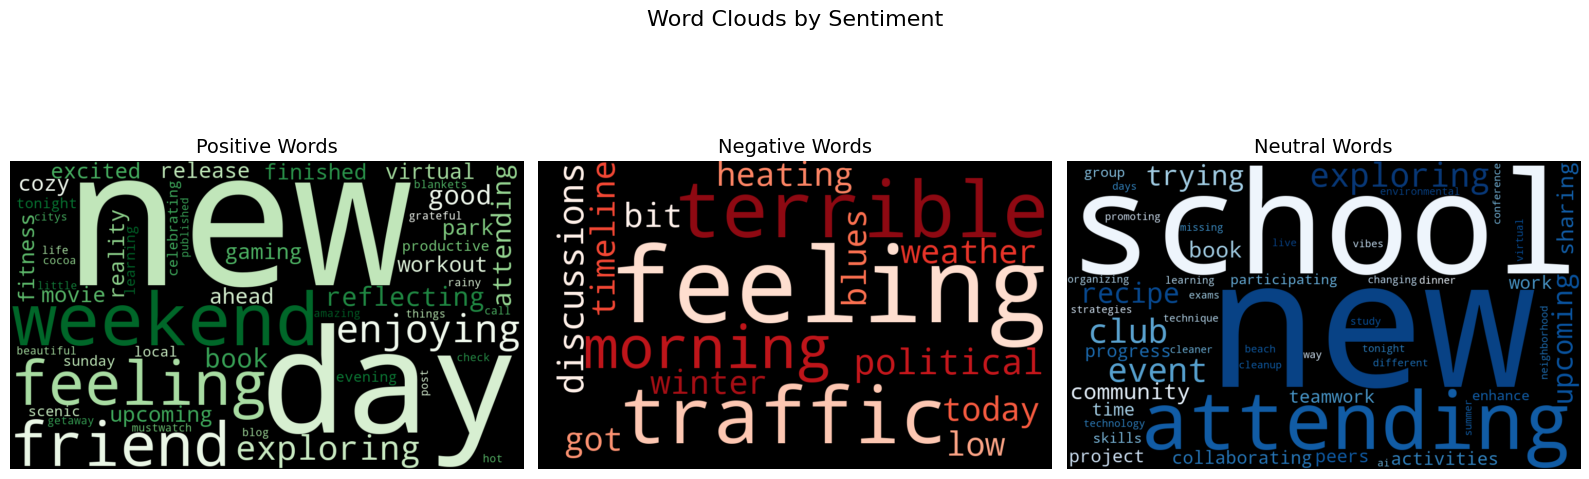

Word clouds saved!


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
sentiments = ['Positive', 'Negative', 'Neutral']
colors = ['Greens', 'Reds', 'Blues']

for i, sentiment in enumerate(sentiments):
    text = ' '.join(df[df['Sentiment'] == sentiment]['Cleaned_Text'])
    
    wordcloud = WordCloud(
        width=1000,
        height=600,
        background_color='black',
        colormap=colors[i],
        max_words=50
    ).generate(text)
    
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'{sentiment} Words', fontsize=14)
    axes[i].axis('off')

plt.suptitle('Word Clouds by Sentiment', fontsize=16)
plt.tight_layout()
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 3\wordclouds.png')
plt.show()
print("Word clouds saved!")

<Figure size 600x400 with 0 Axes>

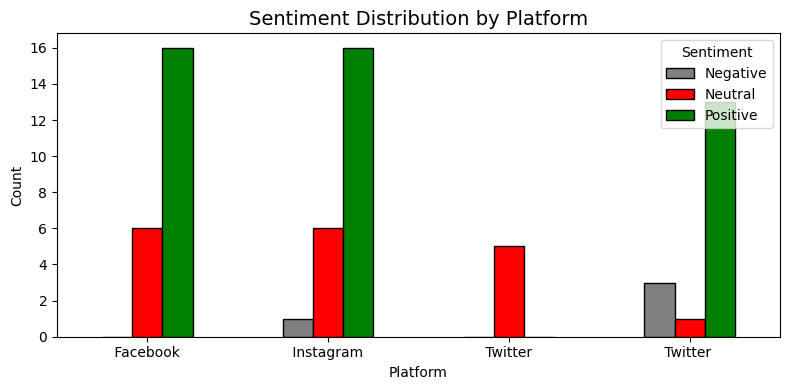

Platform sentiment chart saved!


In [38]:
plt.figure(figsize=(6, 4))
platform_sentiment = df.groupby(['Platform', 'Sentiment']).size().unstack(fill_value=0)
platform_sentiment.plot(
    kind='bar',
    figsize=(8, 4),
    color=['gray', 'red', 'green'],
    edgecolor='black'
)
plt.title('Sentiment Distribution by Platform', fontsize=14)
plt.xlabel('Platform')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 3\sentiment_by_platform.png')
plt.show()
print("Platform sentiment chart saved!")

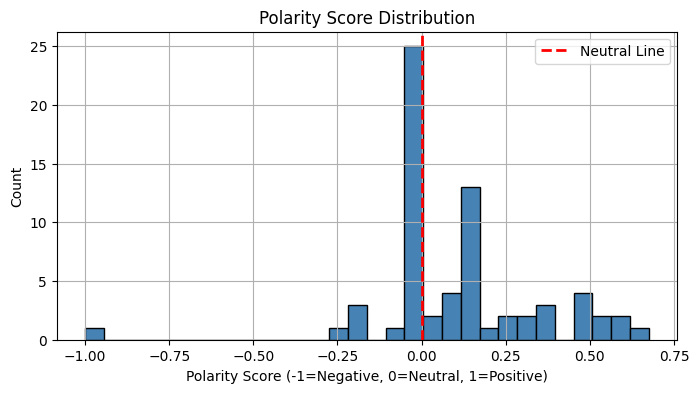

Polarity distribution chart saved!


In [40]:
plt.figure(figsize=(8, 4))
df['Polarity'].hist(
    bins=30,
    color='steelblue',
    edgecolor='black'
)
plt.title('Polarity Score Distribution', fontsize=12)
plt.xlabel('Polarity Score (-1=Negative, 0=Neutral, 1=Positive)')
plt.ylabel('Count')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Neutral Line')
plt.legend()
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 3\polarity_distribution.png')
plt.show()
print("Polarity distribution chart saved!")

<Figure size 1200x600 with 0 Axes>

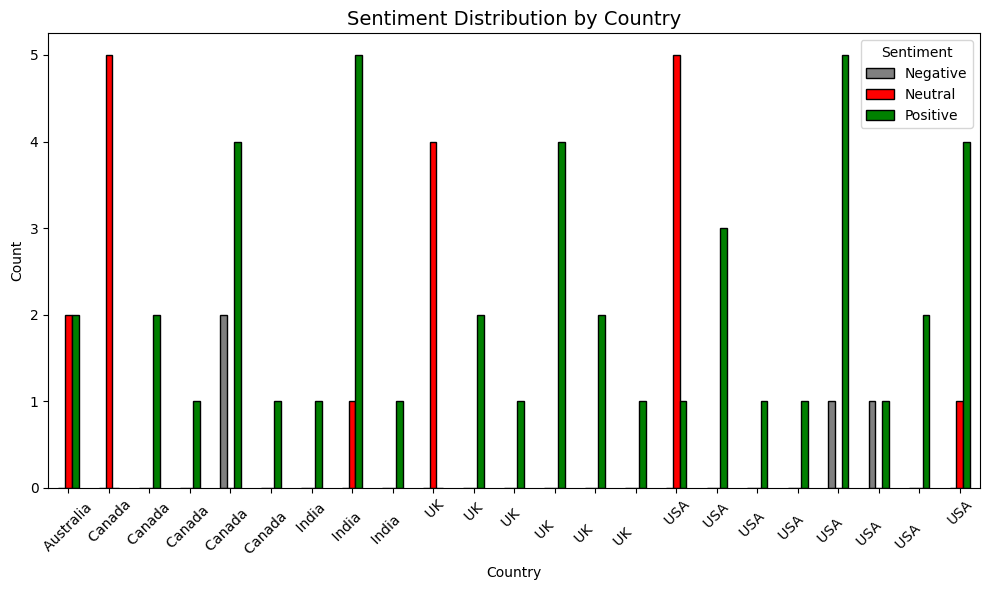

Country sentiment chart saved!


In [43]:
plt.figure(figsize=(12, 6))
country_sentiment = df.groupby(['Country', 'Sentiment']).size().unstack(fill_value=0)
country_sentiment.plot(
    kind='bar',
    figsize=(10, 6),
    color=['gray', 'red', 'green'],
    edgecolor='black'
)
plt.title('Sentiment Distribution by Country', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 3\sentiment_by_country.png')
plt.show()
print("Country sentiment chart saved!")